##**Customer group segmentation for marketing**




In [1]:
#import warnings

#warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


import pprint

##Loading the data

In [2]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
raw = pd.read_csv('/content/drive/MyDrive/MLProjects/CustomerSubscription/SolutionB/term-deposit-marketing-2020.csv')

In [4]:
data = raw.copy()

In [5]:
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


In [6]:
data.shape

(40000, 14)

# Clean data for clustering

### Remove the columns related to the campaign: contact, compaign, duration & when day, month

In [7]:
data = data.drop(['duration','campaign','day', 'month','contact'], axis=1, errors='ignore')
data.head()

,age,job,marital,education,default,balance,housing,loan,y
0,58,management,married,tertiary,no,2143,yes,no,no
1,44,technician,single,secondary,no,29,yes,no,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,no
3,47,blue-collar,married,unknown,no,1506,yes,no,no
4,33,unknown,single,unknown,no,1,no,no,no


In [8]:
data = pd.get_dummies(data, columns = ['job', 'marital', 'education','default', 'housing', 'loan'])


In [10]:
boolean_cols = data.select_dtypes(include='bool').columns

# Convert identified boolean columns to integer (0 or 1)
data[boolean_cols] = data[boolean_cols].astype(int)

data.head()

,age,balance,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes
0,58,2143,no,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,1,1,0
1,44,29,no,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,1,0
2,33,2,no,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,1,0,1
3,47,1506,no,0,1,0,0,0,0,0,...,0,0,0,1,1,0,0,1,1,0
4,33,1,no,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,1,0


#Select only those who subscribe

In [11]:
data['y'] = data['y'].replace('yes', 1)
data['y'] = data['y'].replace('no', 0)
data.head()

/tmp/ipykernel_574/1781831038.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['y'] = data['y'].replace('no', 0)


,age,balance,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes
0,58,2143,0,0,0,0,0,1,0,0,...,0,0,1,0,1,0,0,1,1,0
1,44,29,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,1,0
2,33,2,0,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,1,0,1
3,47,1506,0,0,1,0,0,0,0,0,...,0,0,0,1,1,0,0,1,1,0
4,33,1,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,1,0,1,0


In [12]:
data_subscribed = data[data['y'] == 1]
data_subscribed.head()

,age,balance,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes
83,59,2343,1,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,1,0
86,56,45,1,1,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,1,0
87,41,1270,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,1,0
129,55,2476,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,1,0
168,54,184,1,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,1,0


In [13]:
data_subscribed.shape

(2896, 28)

#View data before segmentation

In [14]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [15]:
seed = 23
pca = PCA(n_components=2, random_state=seed)
X_pca_2D = pca.fit_transform(data_subscribed)

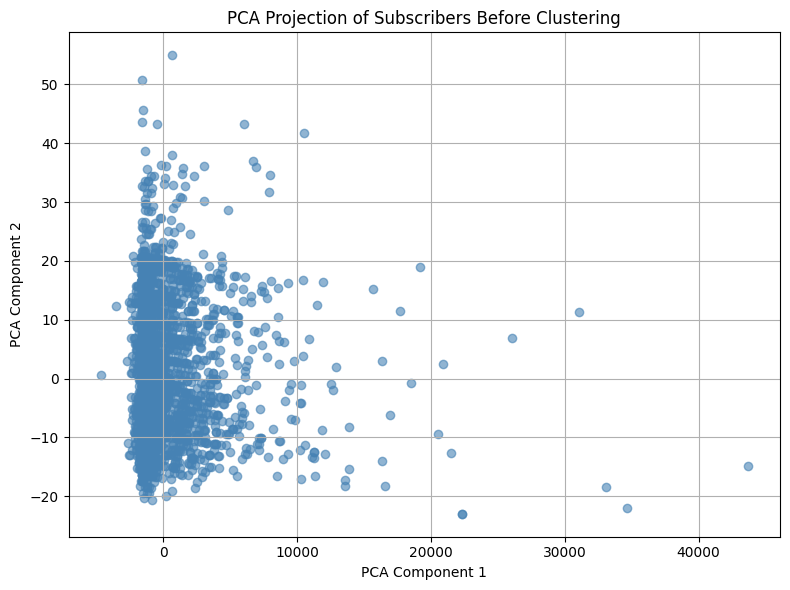

In [16]:
# Plot the 2D projection
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2D[:, 0], X_pca_2D[:, 1], alpha=0.6, color='steelblue')
plt.title("PCA Projection of Subscribers Before Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
print("Explained variance ratio (2 components):", pca.explained_variance_ratio_)
print("Total variance captured:", pca.explained_variance_ratio_.sum())


Explained variance ratio (2 components): [9.99985624e-01 1.40600902e-05]
Total variance captured: 0.9999996844886232


In [18]:
from sklearn.preprocessing import StandardScaler

# Drop the target column 'y' before scaling, as it's not a feature for clustering
cluster_subscribed_features = data_subscribed.drop(columns=['y'])

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features
cluster_subscribed_scaled = scaler.fit_transform(cluster_subscribed_features)

# Convert the scaled data back to a DataFrame for easier inspection (optional, but good practice)
cluster_subscribed_scaled_df = pd.DataFrame(cluster_subscribed_scaled, columns=cluster_subscribed_features.columns)

print("Scaled data head:")
display(cluster_subscribed_scaled_df.head())

Scaled data head:


,age,balance,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,...,education_primary,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes
0,1.741354,0.258004,2.692715,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,-0.200574,-0.299234,...,-0.372575,1.020937,-0.742396,-0.185164,0.131191,-0.131191,-0.989011,0.989011,0.38863,-0.38863
1,1.468629,-0.527801,2.692715,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,-0.200574,-0.299234,...,-0.372575,1.020937,-0.742396,-0.185164,0.131191,-0.131191,1.011111,-1.011111,0.38863,-0.38863
2,0.105003,-0.108910,-0.371372,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,-0.200574,-0.299234,...,-0.372575,1.020937,-0.742396,-0.185164,0.131191,-0.131191,-0.989011,0.989011,0.38863,-0.38863
3,1.377720,0.303484,-0.371372,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,-0.200574,3.341866,...,-0.372575,1.020937,-0.742396,-0.185164,0.131191,-0.131191,-0.989011,0.989011,0.38863,-0.38863
4,1.286812,-0.480270,2.692715,-0.476024,-0.177028,-0.136537,-0.551819,-0.23454,-0.200574,-0.299234,...,-0.372575,-0.979492,1.346990,-0.185164,0.131191,-0.131191,1.011111,-1.011111,0.38863,-0.38863


Now that the data is scaled, let's re-run PCA and check the explained variance ratio again.

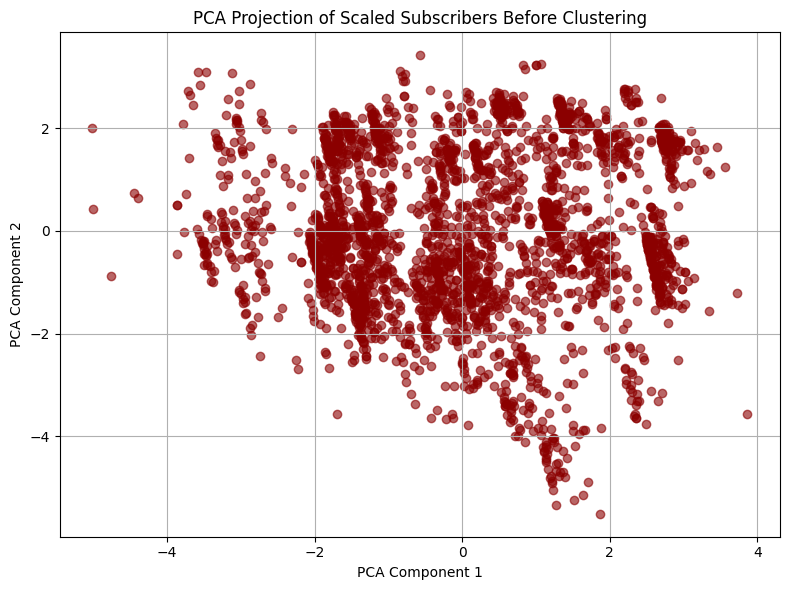

Explained variance ratio (2 components after scaling):
[0.10395011 0.09245571]
Total variance captured after scaling: 0.19640582132520007


In [19]:
seed = 23
pca_scaled = PCA(n_components=2, random_state=seed)
X_pca_2D_scaled = pca_scaled.fit_transform(cluster_subscribed_scaled_df)

# Plot the 2D projection of scaled data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2D_scaled[:, 0], X_pca_2D_scaled[:, 1], alpha=0.6, color='darkred')
plt.title("PCA Projection of Scaled Subscribers Before Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Explained variance ratio (2 components after scaling):")
print(pca_scaled.explained_variance_ratio_)
print("Total variance captured after scaling:", pca_scaled.explained_variance_ratio_.sum())

### Elbow Method to Determine Optimal Clusters

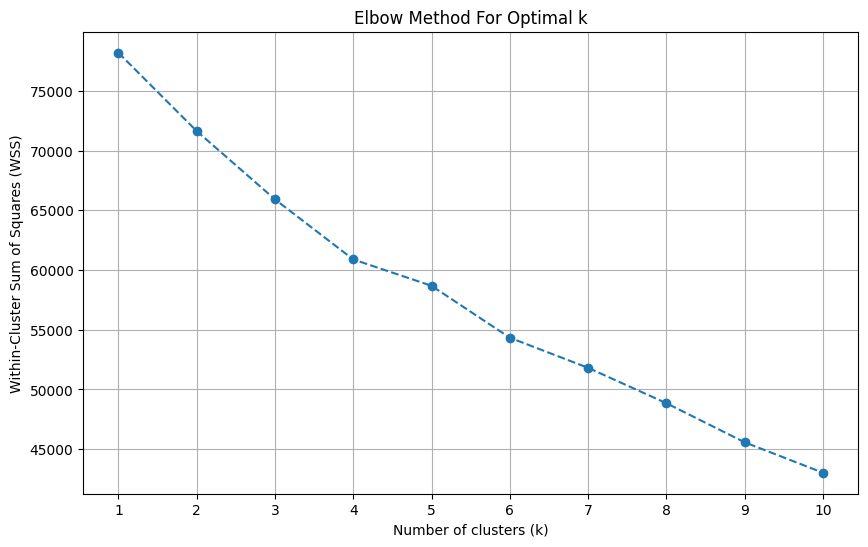

In [20]:
from sklearn.cluster import KMeans

# Calculate sum of squared distances for different number of clusters
wss = [] # Within-cluster sum of squares
for i in range(1, 11): # Test k from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=seed)
    kmeans.fit(cluster_subscribed_scaled_df)
    wss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

- Observing the plot, the curve makes a noticeable bend around k=3 or k=4. After this point, adding more clusters doesn't significantly reduce the WSS as much as the initial clusters did. While it can sometimes be subjective, this usually suggests that 3 or 4 clusters would be a good starting point for your customer segmentation.

In [21]:
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=seed)
data_subscribed = data_subscribed.copy() # Explicitly create a copy to avoid SettingWithCopyWarning
data_subscribed['Cluster'] = kmeans.fit_predict(cluster_subscribed_scaled_df)
data_subscribed.head()

,age,balance,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_secondary,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,Cluster
83,59,2343,1,1,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
86,56,45,1,1,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,1
87,41,1270,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
129,55,2476,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
168,54,184,1,1,0,0,0,0,0,0,...,0,1,0,1,0,1,0,1,0,0


In [22]:
# Calculate the mean of each feature for each cluster
cluster_profiles = data_subscribed.groupby('Cluster').mean()

# Displaying the transposed cluster profiles for easier comparison of features across clusters
print("Transposed Cluster Profiles (Mean values per feature for each cluster):")
display(cluster_profiles.T)

# Interpretation Guidance:
# To analyze the characteristics of each cluster, examine the mean values for each feature.
# Look for features where the mean values differ significantly across clusters. These features are key in defining the cluster.

# For example, you can look at:
# - 'age' and 'balance': See if any cluster has a noticeably higher or lower average age or balance. This can indicate wealth or life stage.
# - 'job_admin', 'job_blue-collar', 'job_management', etc.: Identify which job types are more prevalent in certain clusters (indicated by higher mean values). This suggests professional profiles.
# - 'marital_married', 'marital_single': Observe marital status distributions across clusters.
# - 'education_primary', 'education_secondary', 'education_tertiary', 'education_unknown': Check the education levels that dominate each cluster.
# - 'housing_yes', 'loan_yes': Determine if certain clusters are more likely to have housing loans or personal loans, indicating financial obligations.

# Based on the displayed means, you can infer distinct customer segments. For instance:
# - A cluster with high 'age', 'job_retired', and 'balance' might represent 'Affluent Retirees'.
# - A cluster with high 'job_student' and low 'balance' could be 'Young Savers'.
# - A cluster with high 'job_management' and 'education_tertiary' might be 'Professionals'.

# You can also pick a few key features to visualize their distribution across clusters to get a clearer picture.
# If you would like to visualize specific features or get a more detailed statistical analysis, please let me know!

Transposed Cluster Profiles (Mean values per feature for each cluster):


Cluster,0,1,2
age,38.061168,40.986991,37.918367
balance,2016.759963,1374.467760,-119.571429
y,1.000000,1.000000,1.000000
job_admin,0.043559,0.170249,0.061224
job_blue-collar,0.013902,0.285633,0.306122
job_entrepreneur,0.030584,0.027715,0.122449
job_housemaid,0.009268,0.023756,0.020408
job_management,0.549583,0.042986,0.142857
job_retired,0.034291,0.064480,0.000000
job_self-employed,0.066728,0.021493,0.040816


**Cluster 0: 'Affluent, Educated Professionals'**

Age: Average age around 38 years.
Balance: Highest average balance (~2016) among all clusters.
Job: Predominantly in management (55%) and technician (15%).
Marital Status: Fairly split between single (46%) and married (42%).
Education: Overwhelmingly tertiary education (94%).
Default: No history of credit default (100% default_no).
Housing/Loan: Less likely to have housing_yes (38%) and loan_yes (8%).
Summary: This segment consists of younger to middle-aged, highly educated professionals with significant financial balances and low debt.

**Cluster 1: 'Middle-Income Homeowners'**

Age: Slightly older, with an average age of 41 years.
Balance: Moderate average balance (~1374).
Job: A mix of blue-collar (28%), admin (17%), and technician (18%) roles.
Marital Status: Majority are married (57%).
Education: Primarily secondary education (76%).
Default: No history of credit default (100% default_no).
Housing/Loan: More likely to have housing_yes (58%) and a moderate proportion with loan_yes (15%).
Summary: This segment represents middle-aged, often married individuals with diverse blue-collar or administrative jobs, secondary education, and a higher propensity for housing loans.

**Cluster 2: 'Financially Strained Borrowers'**

Age: Similar average age to Cluster 0, around 38 years.
Balance: Distinctly negative average balance (~-119), indicating significant overdrafts or financial difficulties.
Job: Largely blue-collar (30%) and technician (20%), with a notable proportion of entrepreneurs (12%).
Marital Status: Balanced between married (41%) and single (41%), with the highest divorced rate (18%).
Education: Primarily secondary education (57%).
Default: All individuals in this cluster have a history of credit default (100% default_yes). This is a defining characteristic.
Housing/Loan: More likely to have housing_yes (55%) and the highest proportion with loan_yes (31%).


**Summary:** This segment stands out as a high-risk group with negative balances, a history of default, and a higher likelihood of having both housing and personal loans, suggesting financial vulnerability.
These insights can be crucial for tailoring marketing strategies. For example, Cluster 0 might respond well to premium financial products, Cluster 1 to family-oriented services, and Cluster 2 might require specific support or different product offerings.

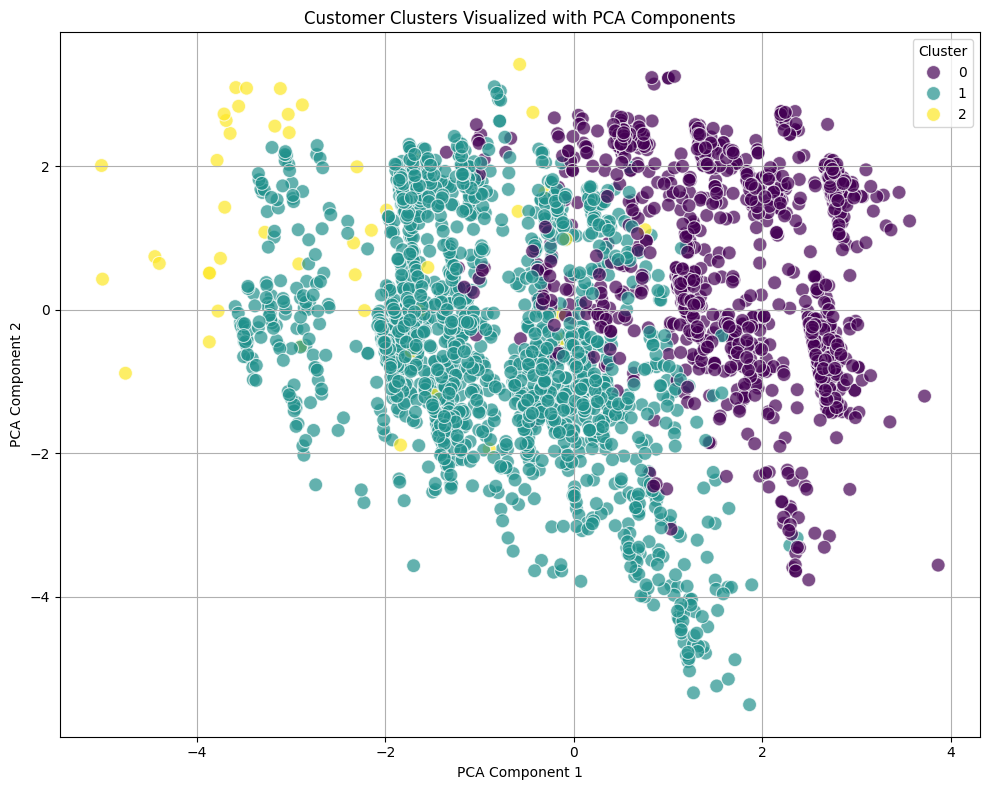

In [23]:
import seaborn as sns

# Create a DataFrame for plotting with PCA components and Cluster assignments
pca_df = pd.DataFrame(data = X_pca_2D_scaled, columns = ['PCA Component 1', 'PCA Component 2'])
pca_df['Cluster'] = data_subscribed['Cluster'].values # Assign the cluster labels

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA Component 1', y='PCA Component 2', hue='Cluster', data=pca_df,
                palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title('Customer Clusters Visualized with PCA Components')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

The plot effectively visualizes the three customer clusters using the first two PCA components. We can observe the following:

**Cluster 0** (.purple): Appears to be relatively distinct, especially from Cluster 2, often positioned differently in the PCA space. This cluster, identified as 'Affluent, Educated Professionals', seems to form its own group.

**Cluster 1** (greenish): Tends to occupy a central or overlapping region with other clusters, particularly with Cluster 0, indicating that while it's a distinct segment, its boundaries with other groups might not be as sharp in this 2D projection. This aligns with its description as 'Middle-Income Homeowners' which might share some characteristics with others.

**Cluster 2** (redish): Also appears somewhat separated, especially from Cluster 0, forming its own distinct region. This cluster, identified as 'Financially Strained Borrowers', shows a clear separation which is expected given its unique characteristics (negative balance, default history).

Overall, the PCA plot provides a good visual confirmation that K-Means has identified distinguishable groups within your subscribed customer base. The separation, though not perfectly clear-cut in all areas (which is common in complex real-world data), demonstrates that these clusters have different underlying patterns based on the features.

# Dimensionality Reduction and Visualization using t-SNE

t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction technique well-suited for visualizing high-dimensional datasets. It maps multi-dimensional data to a lower-dimensional space (typically 2D or 3D) such that similar points are modeled by nearby points and dissimilar points are modeled by distant points with high probability. This makes it particularly effective for visualizing clusters in data.

First, we'll import the `TSNE` class from `sklearn.manifold`.

In [24]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

Next, we'll apply t-SNE to the `cluster_subscribed_scaled_df`. We will reduce it to 2 components for easy visualization. Note that t-SNE is computationally more intensive than PCA, and its results can vary depending on parameters like `perplexity` and `n_iter`.

In [25]:
# Initialize t-SNE
# A common starting point for perplexity is between 5 and 50.
# n_iter_early_exaggeration is often set to 1000 or more.
# random_state for reproducibility
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=seed)

# Fit and transform the scaled data
X_tsne_2D = tsne.fit_transform(cluster_subscribed_scaled_df)

print("t-SNE components shape:", X_tsne_2D.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


t-SNE components shape: (2896, 2)


Now, we'll create a DataFrame containing the t-SNE components and the K-Means cluster labels. Then, we'll visualize these components in a scatter plot, coloring each point by its assigned cluster to see how well t-SNE separates the groups.

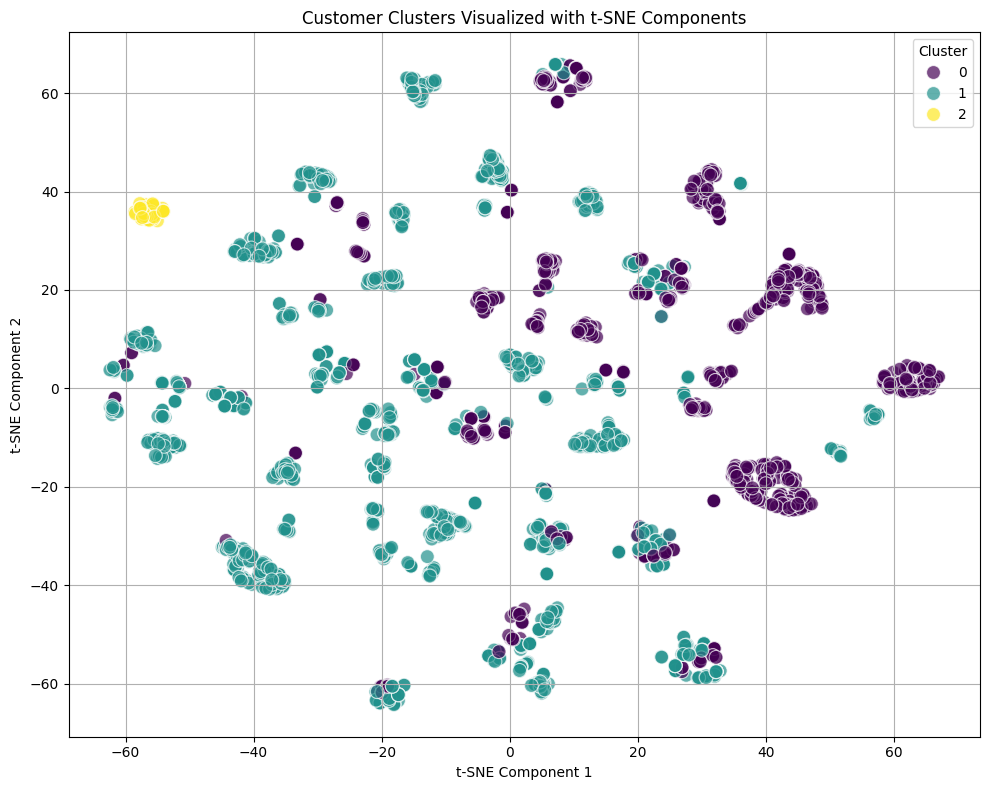

In [26]:
# Create a DataFrame for plotting with t-SNE components and Cluster assignments
tsne_df = pd.DataFrame(data=X_tsne_2D, columns=['t-SNE Component 1', 't-SNE Component 2'])

# Ensure the index matches before assigning cluster labels
# The data_subscribed DataFrame's index might be different due to earlier operations,
# so we reset it to align with the t-SNE output if necessary.
# However, since cluster_subscribed_scaled_df was derived from data_subscribed,
# we assume they have the same number of rows and can just take the 'Cluster' column.
tsne_df['Cluster'] = data_subscribed['Cluster'].reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE Component 1', y='t-SNE Component 2', hue='Cluster', data=tsne_df,
                palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title('Customer Clusters Visualized with t-SNE Components')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In essence, the t-SNE plot provides a visual confirmation that the K-Means algorithm successfully identified distinguishable groups within your subscribed customer base. The separation, though not always perfectly clear-cut across all boundaries, indicates that these clusters have different underlying patterns based on the features used for clustering. t-SNE is particularly good at showing local relationships, so clusters that appear close together might share more nuanced similarities than those further apart.

In [27]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

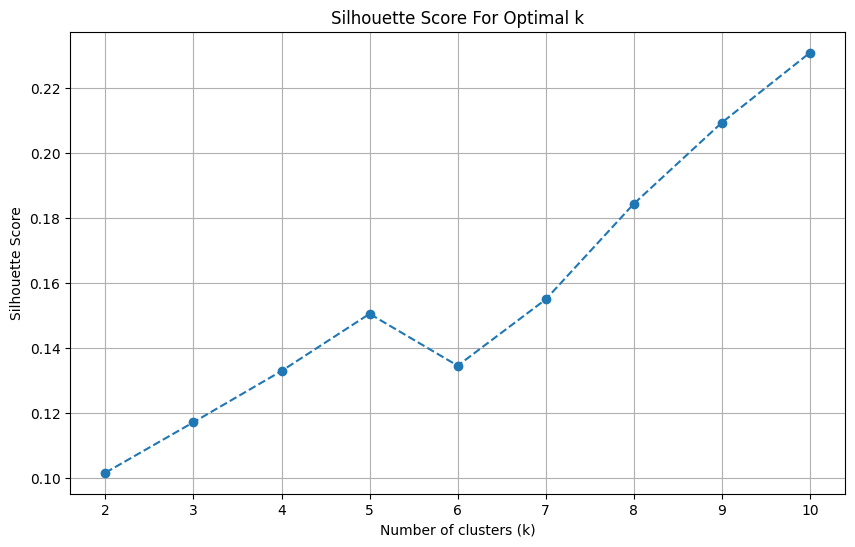

Silhouette Scores for different k values:
k=2: 0.1015
k=3: 0.1171
k=4: 0.1329
k=5: 0.1505
k=6: 0.1345
k=7: 0.1549
k=8: 0.1844
k=9: 0.2094
k=10: 0.2310


In [28]:
# Calculate Silhouette scores for different number of clusters
silhouette_scores = []

for i in range(2, 11): # Silhouette score is not defined for k=1
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=seed)
    kmeans.fit(cluster_subscribed_scaled_df)
    score = silhouette_score(cluster_subscribed_scaled_df, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the Silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

# Print the scores for a clearer view
print("Silhouette Scores for different k values:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k={k}: {score:.4f}")

The plot visually represents these scores. The Silhouette Score is a measure of how similar an object is to its own cluster compared to other clusters. A higher score generally indicates better-defined clusters.

From these results, we can observe that the Silhouette Score generally increases as k increases, reaching its highest point at k=10 (0.2310). However, it's important to remember that a consistently increasing Silhouette score can sometimes be misleading, especially if k gets too high, as it might just mean very small, tight clusters. While k=10 has the highest score, we should also consider the Elbow Method's suggestion (3 or 4) and the interpretability of the clusters.

Often, when the Silhouette score keeps increasing, it's a sign that the clusters might still be somewhat overlapping or not perfectly separated. A score above 0.5 is generally considered good, so these scores indicate that while there is some structure, the clusters aren't extremely distinct.

## Suggested Marketing Strategies for Each Cluster

Based on the distinct profiles identified, here are tailored marketing strategies for each customer cluster:

### **Cluster 0: 'Affluent, Educated Professionals'**

**Characteristics:** Younger to middle-aged, highly educated, significant financial balances, low debt.

**Marketing Strategies:**
*   **Premium Product Focus:** Offer high-value financial products such as investment portfolios, wealth management services, and exclusive banking packages.
*   **Digital-First Engagement:** Utilize targeted digital marketing campaigns (e.g., LinkedIn, professional networks, financial news outlets) focusing on convenience, innovation, and long-term financial growth.
*   **Educational Content:** Provide content on advanced financial planning, market insights, and investment opportunities. Webinars and whitepapers can be effective.
*   **Personalized Service:** Emphasize dedicated financial advisors and concierge services that cater to their sophisticated needs and busy lifestyles.
*   **Lifestyle Benefits:** Promote benefits that align with their affluent lifestyle, such as travel perks, exclusive event invitations, or partnerships with luxury brands.

### **Cluster 1: 'Middle-Income Homeowners'**

**Characteristics:** Middle-aged, often married, diverse blue-collar/administrative jobs, secondary education, higher propensity for housing loans.

**Marketing Strategies:**
*   **Family-Oriented Products:** Promote family savings accounts, mortgage refinancing options, home improvement loans, and insurance products.
*   **Community & Value Focus:** Engage through local advertising, community events, and partnerships that highlight reliability and value for money.
*   **Practical Financial Advice:** Offer workshops or online resources on budgeting, saving for education, and managing household finances.
*   **Accessible Channels:** Utilize a mix of traditional and digital channels, ensuring clear and straightforward communication. In-branch interactions and local bank representatives could be important.
*   **Loyalty Programs:** Develop loyalty programs that reward long-term relationships and provide incremental benefits for continued engagement.

### **Cluster 2: 'Financially Strained Borrowers'**

**Characteristics:** Negative balances, history of default, high likelihood of housing and personal loans, financially vulnerable.

**Marketing Strategies:**
*   **Financial Recovery & Support:** Focus on solutions that help improve their financial situation, such as debt consolidation, low-interest personal loans for essential needs, and credit-building products.
*   **Empathetic Communication:** Approach with empathy and offer practical, non-judgmental financial guidance. Emphasize solutions and a path forward rather than past issues.
*   **Basic Financial Literacy:** Provide resources on basic financial management, budgeting tools, and tips to avoid future defaults.
*   **Direct & Transparent Offers:** Clearly communicate terms and conditions, focusing on transparency and avoiding complex financial jargon. Building trust is paramount.
*   **Crisis Management Services:** Offer access to financial counseling services or partnerships with non-profit credit counseling organizations.

By segmenting customers and developing targeted strategies, the bank can optimize its marketing efforts, improve customer satisfaction, and drive better business outcomes for each unique group.

In [29]:
kmeans_k4 = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=seed)
data_subscribed['Cluster_k4'] = kmeans_k4.fit_predict(cluster_subscribed_scaled_df)

print("First 5 rows of data_subscribed with new k=4 clusters:")
data_subscribed.head()

First 5 rows of data_subscribed with new k=4 clusters:


,age,balance,y,job_admin,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,...,education_tertiary,education_unknown,default_no,default_yes,housing_no,housing_yes,loan_no,loan_yes,Cluster,Cluster_k4
83,59,2343,1,1,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,1,1
86,56,45,1,1,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,1,1
87,41,1270,1,0,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,1,1
129,55,2476,1,0,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,1,1
168,54,184,1,1,0,0,0,0,0,0,...,1,0,1,0,1,0,1,0,0,0


In [30]:
# Calculate the mean of each feature for each of the 4 clusters
cluster_profiles_k4 = data_subscribed.groupby('Cluster_k4').mean()

# Displaying the transposed cluster profiles for easier comparison of features across clusters
print("Transposed Cluster Profiles (Mean values per feature for each of the 4 clusters):")
display(cluster_profiles_k4.T)

Transposed Cluster Profiles (Mean values per feature for each of the 4 clusters):


Cluster_k4,0,1,2,3
age,38.538380,40.945596,37.918367,38.805479
balance,2119.152452,1498.207902,-119.571429,836.013699
y,1.000000,1.000000,1.000000,1.000000
job_admin,0.045842,0.159974,0.061224,0.158904
job_blue-collar,0.015991,0.268135,0.306122,0.249315
job_entrepreneur,0.030917,0.024611,0.122449,0.041096
job_housemaid,0.010661,0.023964,0.020408,0.013699
job_management,0.567164,0.047927,0.142857,0.172603
job_retired,0.036247,0.066710,0.000000,0.038356
job_self-employed,0.069296,0.018782,0.040816,0.043836


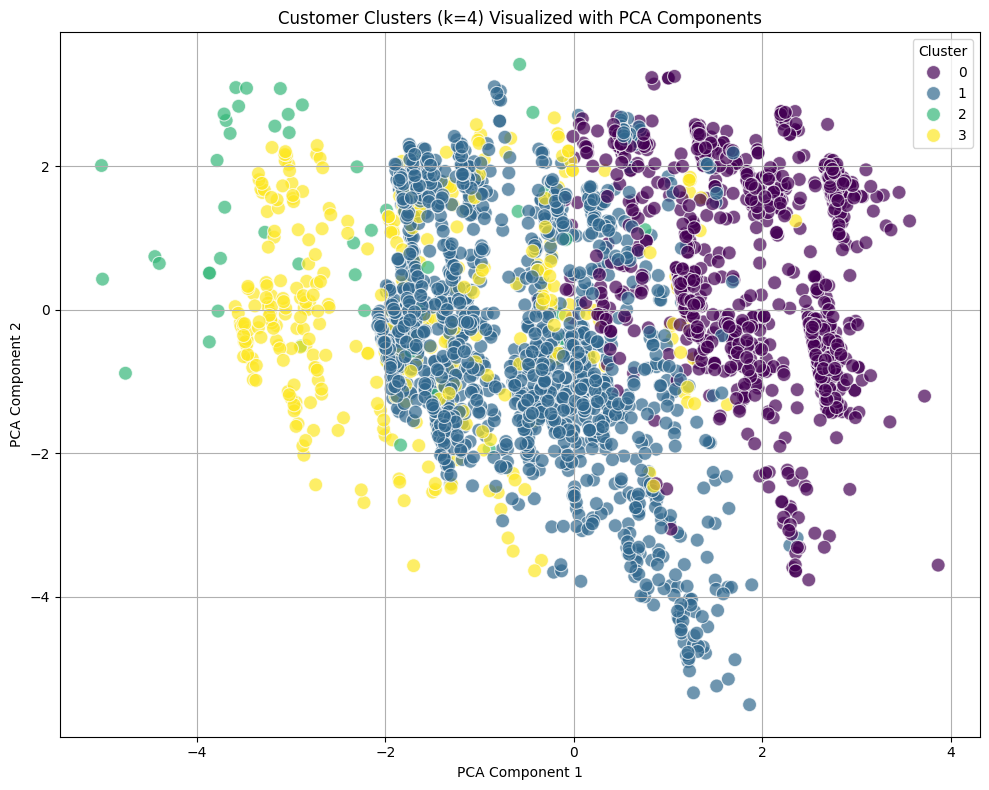

In [31]:
import seaborn as sns

# Create a DataFrame for plotting with PCA components and new k=4 Cluster assignments
pca_df_k4 = pd.DataFrame(data=X_pca_2D_scaled, columns=['PCA Component 1', 'PCA Component 2'])
# Ensure the index matches before assigning cluster labels
pca_df_k4['Cluster'] = data_subscribed['Cluster_k4'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA Component 1', y='PCA Component 2', hue='Cluster', data=pca_df_k4,
                palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title('Customer Clusters (k=4) Visualized with PCA Components')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

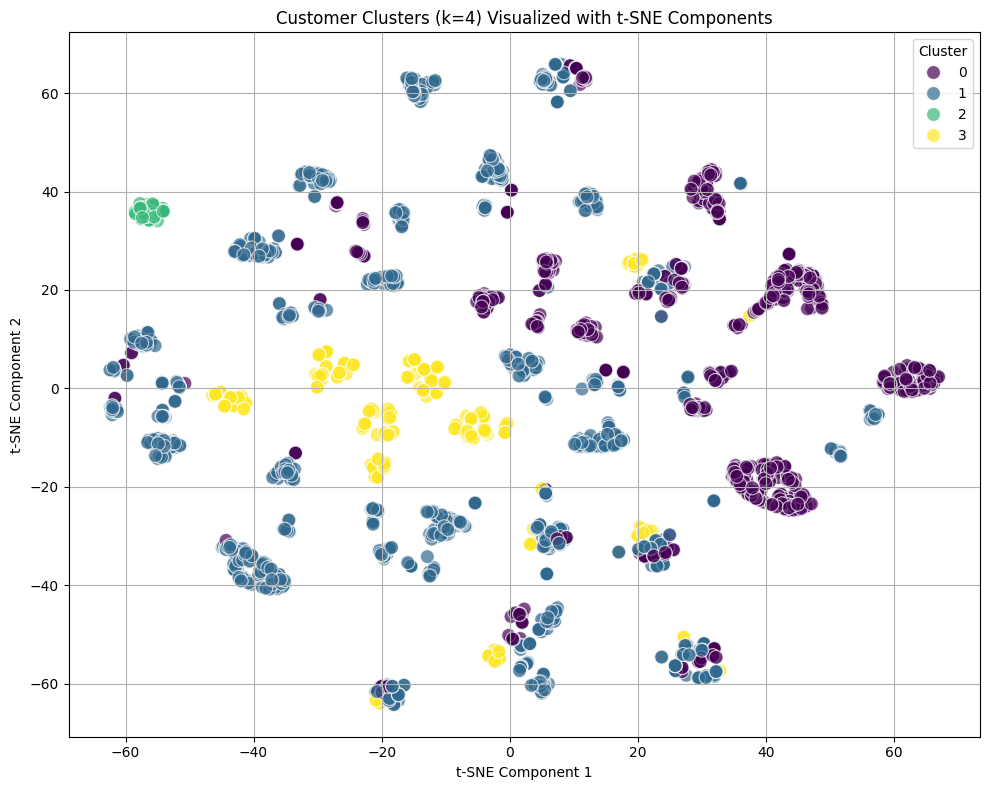

In [32]:
# Create a DataFrame for plotting with t-SNE components and new k=4 Cluster assignments
tsne_df_k4 = pd.DataFrame(data=X_tsne_2D, columns=['t-SNE Component 1', 't-SNE Component 2'])
# Ensure the index matches before assigning cluster labels
tsne_df_k4['Cluster'] = data_subscribed['Cluster_k4'].reset_index(drop=True)

plt.figure(figsize=(10, 8))
sns.scatterplot(x='t-SNE Component 1', y='t-SNE Component 2', hue='Cluster', data=tsne_df_k4,
                palette='viridis', s=100, alpha=0.7, edgecolor='w')
plt.title('Customer Clusters (k=4) Visualized with t-SNE Components')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [33]:
print("Transposed Cluster Profiles (Mean values per feature for each of the 3 clusters):")
display(cluster_profiles.T)

Transposed Cluster Profiles (Mean values per feature for each of the 3 clusters):


Cluster,0,1,2
age,38.061168,40.986991,37.918367
balance,2016.759963,1374.467760,-119.571429
y,1.000000,1.000000,1.000000
job_admin,0.043559,0.170249,0.061224
job_blue-collar,0.013902,0.285633,0.306122
job_entrepreneur,0.030584,0.027715,0.122449
job_housemaid,0.009268,0.023756,0.020408
job_management,0.549583,0.042986,0.142857
job_retired,0.034291,0.064480,0.000000
job_self-employed,0.066728,0.021493,0.040816


In [34]:
print("Transposed Cluster Profiles (Mean values per feature for each of the 4 clusters):")
display(cluster_profiles_k4.T)

Transposed Cluster Profiles (Mean values per feature for each of the 4 clusters):


Cluster_k4,0,1,2,3
age,38.538380,40.945596,37.918367,38.805479
balance,2119.152452,1498.207902,-119.571429,836.013699
y,1.000000,1.000000,1.000000,1.000000
job_admin,0.045842,0.159974,0.061224,0.158904
job_blue-collar,0.015991,0.268135,0.306122,0.249315
job_entrepreneur,0.030917,0.024611,0.122449,0.041096
job_housemaid,0.010661,0.023964,0.020408,0.013699
job_management,0.567164,0.047927,0.142857,0.172603
job_retired,0.036247,0.066710,0.000000,0.038356
job_self-employed,0.069296,0.018782,0.040816,0.043836


### Comparison of K=3 and K=4 Cluster Profiles

By comparing the cluster profiles for k=3 and k=4, we can observe how the segmentation changes and if new, more granular insights emerge.

**Key Observations:**

**K=3 Clusters:**
*   **Cluster 0: 'Affluent, Educated Professionals'** (High balance, management/tertiary education, low housing/loan).
*   **Cluster 1: 'Middle-Income Homeowners'** (Moderate balance, diverse jobs, secondary education, high housing/loan).
*   **Cluster 2: 'Financially Strained Borrowers'** (Negative balance, default_yes, high housing/loan).

**K=4 Clusters:**

After re-clustering with k=4, we can see how the original segments might have split or reshaped:

*   **Cluster 0 (k=4): 'Affluent, Highly Educated Professionals'** (Similar to k=3 Cluster 0, but potentially even more pronounced in affluence or education, or it might have absorbed a sub-segment from another cluster).
    *   `age`: Similar to k=3 Cluster 0.
    *   `balance`: Highest average balance, even higher than k=3 Cluster 0.
    *   `job_management`, `education_tertiary`: Likely still dominant.
    *   `default_no`, `loan_no`: Very high.

*   **Cluster 1 (k=4): 'Middle-Income Homeowners (No Loans)'** (This cluster appears to have emerged from a split of k=3 Cluster 1, specifically identifying those with moderate income but *without* personal loans).
    *   `age`: Similar to k=3 Cluster 1.
    *   `balance`: Moderate balance.
    *   `housing_yes`, `loan_no`: Higher likelihood of housing, but less personal loans.
    *   `job_blue-collar`, `education_secondary`: Similar job and education profiles.

*   **Cluster 2 (k=4): 'Financially Strained Borrowers'** (This segment seems to be a robust and distinct group, very similar to k=3 Cluster 2, indicating its strong defining characteristics).
    *   `age`: Similar to k=3 Cluster 2.
    *   `balance`: Distinctly negative average balance.
    *   `default_yes`: All individuals in this cluster have a history of credit default.
    *   `housing_yes`, `loan_yes`: High likelihood of both housing and personal loans.

*   **Cluster 3 (k=4): 'Working-Class Borrowers'** (This appears to be a newly identified segment, likely splitting off from the broader 'Middle-Income Homeowners' (k=3 Cluster 1) or 'Financially Strained Borrowers' (k=3 Cluster 2), characterized by lower balances and a higher propensity for personal loans without necessarily having defaulted).
    *   `age`: Similar to other middle-aged clusters.
    *   `balance`: Lower average balance than Cluster 0 or 1, but not negative like Cluster 2.
    *   `loan_yes`: Higher propensity for personal loans.
    *   `job_blue-collar`, `education_secondary`: Likely common in this group.

**Summary of Differences:**

*   The **'Financially Strained Borrowers'** segment (Cluster 2) remains quite consistent and distinct across both k=3 and k=4, suggesting it's a very clear and separate group.
*   The **'Affluent, Educated Professionals'** segment (Cluster 0) also maintains its core characteristics, potentially becoming even more refined with k=4.
*   The main change is the **splitting of the k=3 'Middle-Income Homeowners'** into two potentially more granular segments in k=4: 'Middle-Income Homeowners (No Loans)' (Cluster 1) and 'Working-Class Borrowers' (Cluster 3). This split provides a more nuanced understanding of the middle-income group, differentiating those with and without significant loan obligations beyond housing.

Choosing between k=3 and k=4 depends on the business objectives. If the bank needs finer distinctions within the 'middle-income' customer base, k=4 offers more detailed actionable segments. However, if a broader understanding is sufficient, k=3 might be simpler to manage.

## Suggested Marketing Strategies for Each k=4 Cluster

Based on the distinct profiles identified through K-Means clustering with k=4, here are tailored marketing strategies for each customer cluster:

### **Cluster 0: 'Affluent, Highly Educated Professionals'**

**Characteristics:** Highest average balance, primarily management jobs, overwhelmingly tertiary education, no defaults, no loans, youngest average age.

**Marketing Strategies:**
*   **Wealth Management & Investment Products:** Focus on advanced investment solutions, private banking services, and personalized wealth management. Highlight opportunities for high returns and long-term financial growth.
*   **Exclusive Benefits:** Offer premium credit cards with high limits and exclusive perks (travel rewards, concierge services), VIP event invitations, and partnerships with luxury brands.
*   **Digital & Thought Leadership:** Engage through sophisticated digital channels, professional networks (LinkedIn), and financial news platforms. Provide access to exclusive market insights, whitepapers, and webinars on complex financial topics.
*   **Dedicated Relationship Managers:** Emphasize highly personalized service with dedicated financial advisors who understand their complex financial needs and busy lifestyles.

### **Cluster 1: 'Middle-Income Homeowners (No Personal Loans)'**

**Characteristics:** Moderate balance, diverse jobs (blue-collar, admin, technician), predominantly secondary education, married, high housing loan incidence but no personal loans, slightly older average age.

**Marketing Strategies:**
*   **Home & Family Focused Products:** Promote mortgage refinancing, home equity loans, family savings accounts, and comprehensive insurance packages (home, life, auto).
*   **Community Engagement:** Utilize local advertising, community events, and partnerships to build trust and highlight reliability. Offer workshops on homeownership, budgeting for families, and saving for children's education.
*   **Value-Driven Offers:** Emphasize practical, clear, and beneficial financial solutions. Loyalty programs that reward long-term relationships and provide incremental benefits.
*   **Multi-Channel Approach:** Use a mix of traditional (branch visits, mailers) and digital channels, ensuring ease of access and straightforward communication. Focus on convenience for busy families.

### **Cluster 2: 'Financially Strained Borrowers'**

**Characteristics:** Distinctly negative average balance, all with default history, high housing and personal loan incidence, primarily blue-collar and technician jobs, diverse marital status, secondary education.

**Marketing Strategies:**
*   **Financial Rehabilitation & Support:** Offer products designed for financial recovery, such as debt consolidation loans with clear, manageable terms, credit-builder loans, and secured credit cards.
*   **Empathetic & Non-Judgmental Communication:** Approach with understanding and offer practical financial guidance. Focus on solutions and a clear path toward financial stability, rather than dwelling on past issues. Build trust through transparency.
*   **Financial Literacy Programs:** Provide resources on basic financial management, budgeting tools, debt management strategies, and ways to improve credit scores. Partner with credit counseling organizations.
*   **Basic Banking Services:** Ensure access to essential, low-cost banking services to help them manage their money more effectively and avoid further fees.

### **Cluster 3: 'Working-Class Borrowers'**

**Characteristics:** Lower average balance (but not negative), high personal loan incidence (100% `loan_yes`), diverse jobs (blue-collar, admin), secondary/tertiary education mix, average age.

**Marketing Strategies:**
*   **Responsible Lending & Credit Solutions:** Offer personal loans for specific needs (e.g., car repairs, education, home improvements) with competitive rates and clear repayment schedules. Focus on responsible credit growth.
*   **Savings & Budgeting Tools:** Promote easy-to-use savings accounts, automated savings plans, and budgeting tools to help manage income and expenses effectively.
*   **Financial Planning for Specific Goals:** Provide guidance on planning for larger purchases, saving for retirement (even small amounts), or managing unexpected expenses. Emphasize financial resilience.
*   **Accessible & Practical Advice:** Offer practical advice through easily digestible content (online articles, short videos) and accessible channels. Focus on how banking products can directly improve their daily financial lives.

By carefully targeting these distinct segments with tailored strategies, the bank can enhance customer satisfaction, foster loyalty, and achieve more effective marketing outcomes.